# 🤖 Layer 4 — Machine Learning Models
## Traffic Accident Hotspot & Severity Pattern Engine
### 100 Indian Cities | 2022 Data | B.Tech CSE (Data Science) Group Project

---

### 📌 What This Notebook Does
This is **Layer 4** of the project — Machine Learning Models.

**What it builds:**
1. **Model 1 — Severity Classifier** → Predicts risk level of a city (Low/Medium/High/Extreme)
2. **Model 2 — Hotspot Risk Scorer** → Scores any city on a 0–100 risk scale
3. **Model 3 — Accident Count Forecaster** → Predicts accident count from city features
4. **SHAP Explainability** → Shows WHY the model made each prediction
5. **Model Evaluation** → Accuracy, Precision, Recall, F1 Score, Confusion Matrix
6. **Saves all models** → So Layer 5 (Dashboard) can load and use them live

> ✅ **You do NOT need to change any code.**
> Just run each cell one by one using **Shift + Enter**.
> Input file needed: `Layer3_FINAL_100Cities_Master.xlsx`

## STEP 1 — Import All Libraries

In [37]:
# ── Standard libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Machine Learning ──
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, mean_absolute_error,
                             mean_squared_error, r2_score, f1_score)
from sklearn.impute import SimpleImputer

# ── XGBoost ──
try:
    from xgboost import XGBClassifier, XGBRegressor
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not found — will use GradientBoosting instead")
    print("   To install: pip install xgboost")

# ── SHAP (Explainability) ──
try:
    import shap
    SHAP_AVAILABLE = True
    print("✅ SHAP available")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP not found — install with: pip install shap")

# ── Model saving ──
import pickle
import os
from pathlib import Path
import json

# ── Chart style ──
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
})

OUTPUT_DIR = Path("layer4_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
MODELS_DIR = OUTPUT_DIR / "saved_models"
MODELS_DIR.mkdir(exist_ok=True)

print("\n✅ All libraries imported!")
print(f"   Output folder : {OUTPUT_DIR.resolve()}")
print(f"   Models folder : {MODELS_DIR.resolve()}")

✅ XGBoost available
✅ SHAP available

✅ All libraries imported!
   Output folder : D:\traffic-accident-engine\notebooks\LAYER 4 FULL COMPLETE(MADE BY AI)\layer4_outputs
   Models folder : D:\traffic-accident-engine\notebooks\LAYER 4 FULL COMPLETE(MADE BY AI)\layer4_outputs\saved_models


## STEP 2 — Load Data & Understand It
> We load the file your Layer 3 teammate produced.
> This file has 100 cities with all cleaned features ready for ML.

In [38]:
# ── Load the Layer 3 output file ──
df = pd.read_excel("Layer3_FINAL_100Cities_Master.xlsx")

print(f"✅ Data loaded successfully!")
print(f"   Total cities  : {len(df)}")
print(f"   Total columns : {len(df.columns)}")
print(f"\n📊 Target variable distribution (what we want to predict):")
print(df['risk_score_label'].value_counts())
print(f"\n📋 Data availability breakdown:")
print(df['data_availability'].value_counts())
print(f"\n📋 First 5 cities preview:")
print(df[['city','accidents_2022','deaths_2022','injured_2022',
          'city_risk_score','risk_score_label','state']].head(5).to_string(index=False))

✅ Data loaded successfully!
   Total cities  : 100
   Total columns : 54

📊 Target variable distribution (what we want to predict):
risk_score_label
Low        70
Medium     27
High        2
Extreme     1
Name: count, dtype: int64

📋 Data availability breakdown:
data_availability
Both Sources     52
OpenCity Only    48
Name: count, dtype: int64

📋 First 5 cities preview:
            city  accidents_2022  deaths_2022  injured_2022  city_risk_score risk_score_label         state
            Agra            1029          548           795            30.57           Medium Uttar Pradesh
       Ahmedabad            1711          488          1305            27.99           Medium       Gujarat
       Prayagraj            1370          603           886            29.29           Medium Uttar Pradesh
        Amritsar             117           82            62             7.03              Low        Punjab
Asansol Durgapur             494          359           309            16.70          

## STEP 3 — Feature Engineering
### What is Feature Engineering?
> Features are the **input columns** we give to the ML model.
> Good features = better predictions.
> We create new meaningful columns from existing data here.

### Important: NaN vs Zero
> Cities with NaN (data not available) get the **median value** filled in.
> Cities with Zero keep their zero — zero means no accidents, not missing data.

In [39]:
# ── Make a clean copy for ML ──
df_ml = df.copy()

# ── Create new features ──

# 1. Death rate per accident (how fatal are accidents in this city?)
df_ml['death_rate'] = np.where(
    df_ml['accidents_2022'] > 0,
    df_ml['deaths_2022'] / df_ml['accidents_2022'],
    0
).round(4)

# 2. Injury rate per accident
df_ml['injury_rate'] = np.where(
    df_ml['accidents_2022'] > 0,
    df_ml['injured_2022'] / df_ml['accidents_2022'],
    0
).round(4)

# 3. Deaths per injured ratio
df_ml['deaths_to_injured_ratio'] = np.where(
    df_ml['injured_2022'] > 0,
    df_ml['deaths_2022'] / df_ml['injured_2022'],
    0
).round(4)

# 4. Is this a high-weather-risk city? (binary: 1 or 0)
df_ml['is_high_weather_risk'] = (
    df_ml['weather_risk_from_api'] == 'High Weather Risk'
).astype(int)

# 5. Is this an extreme DBSCAN hotspot? (binary: 1 or 0)
df_ml['is_dbscan_hotspot'] = (
    df_ml['dbscan_cluster'] == -1
).astype(int)

# 6. Log of accidents (reduces effect of extreme outliers)
df_ml['log_accidents'] = np.log1p(df_ml['accidents_2022'])
df_ml['log_deaths']    = np.log1p(df_ml['deaths_2022'])

# 7. Encode weather condition as number
weather_order = {'Clear':0,'Clouds':1,'Drizzle':2,'Rain':3,
                 'Mist':4,'Haze':5,'Fog':6,'Thunderstorm':7}
df_ml['weather_encoded'] = df_ml['weather_main'].map(weather_order).fillna(0)

print("✅ New features created:")
new_features = ['death_rate','injury_rate','deaths_to_injured_ratio',
                'is_high_weather_risk','is_dbscan_hotspot',
                'log_accidents','log_deaths','weather_encoded']
for f in new_features:
    print(f"   {f:35s} → sample: {df_ml[f].iloc[0]:.4f}")

print(f"\n📊 Death rate (deaths per accident) — top 10 cities:")
print(df_ml[['city','deaths_2022','accidents_2022','death_rate']].nlargest(
    10,'death_rate').to_string(index=False))

✅ New features created:
   death_rate                          → sample: 0.5326
   injury_rate                         → sample: 0.7726
   deaths_to_injured_ratio             → sample: 0.6893
   is_high_weather_risk                → sample: 0.0000
   is_dbscan_hotspot                   → sample: 0.0000
   log_accidents                       → sample: 6.9373
   log_deaths                          → sample: 6.3081
   weather_encoded                     → sample: 0.0000

📊 Death rate (deaths per accident) — top 10 cities:
            city  deaths_2022  accidents_2022  death_rate
        Ludhiana          364             467      0.7794
         Asansol          365             497      0.7344
Asansol Durgapur          359             494      0.7267
        Durgapur          359             494      0.7267
           Patna          198             275      0.7200
        Amritsar           82             117      0.7009
         Dhanbad          114             179      0.6369
        Var

## STEP 4 — Prepare Features & Target Variables
### What are Features and Targets?
> **Features (X)** = Input columns the model learns from
> (like accidents, deaths, weather, etc.)
>
> **Target (y)** = The column the model tries to predict
> (like risk level = Low/Medium/High/Extreme)

In [40]:
# ── Define feature columns (inputs for ALL models) ──
FEATURES = [
    # Core accident data
    'accidents_2022',
    'deaths_2022',
    'injured_2022',
    # Derived rates
    'death_rate',
    'injury_rate',
    'deaths_to_injured_ratio',
    # Log features
    'log_accidents',
    'log_deaths',
    # Weather (from API)
    'temperature_c',
    'humidity_pct',
    'wind_speed_ms',
    'feels_like_c',
    'weather_encoded',
    'is_high_weather_risk',
    # Clustering results from Layer 3
    'is_dbscan_hotspot',
    'kmeans_cluster',
]

# ── Fill NaN values ──
# Use MEDIAN for numeric nulls — preserves data integrity better than 0
imputer = SimpleImputer(strategy='median')
X_raw = df_ml[FEATURES].copy()
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=FEATURES,
    index=X_raw.index
)

print("✅ Features prepared!")
print(f"   Total features : {len(FEATURES)}")
print(f"   Cities (rows)  : {len(X_imputed)}")
print(f"\n📋 Feature list:")
for i, f in enumerate(FEATURES, 1):
    null_before = X_raw[f].isna().sum()
    null_after  = X_imputed[f].isna().sum()
    print(f"   {i:2d}. {f:35s} NaN before={null_before} → after={null_after}")

✅ Features prepared!
   Total features : 16
   Cities (rows)  : 100

📋 Feature list:
    1. accidents_2022                      NaN before=0 → after=0
    2. deaths_2022                         NaN before=0 → after=0
    3. injured_2022                        NaN before=0 → after=0
    4. death_rate                          NaN before=0 → after=0
    5. injury_rate                         NaN before=0 → after=0
    6. deaths_to_injured_ratio             NaN before=0 → after=0
    7. log_accidents                       NaN before=0 → after=0
    8. log_deaths                          NaN before=0 → after=0
    9. temperature_c                       NaN before=0 → after=0
   10. humidity_pct                        NaN before=0 → after=0
   11. wind_speed_ms                       NaN before=0 → after=0
   12. feels_like_c                        NaN before=0 → after=0
   13. weather_encoded                     NaN before=0 → after=0
   14. is_high_weather_risk                NaN before=0 →

In [41]:
# ── Scale features (normalize to same range) ──
# Why? Because accidents (range 0–5000) and humidity (0–100) are very different scales.
# Scaling makes the model treat them fairly.
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_imputed),
    columns=FEATURES,
    index=X_imputed.index
)

# ── Target for Model 1: Severity Classification ──
# risk_score_label = Low / Medium / High / Extreme
le = LabelEncoder()
y_class = le.fit_transform(df_ml['risk_score_label'])
class_names = le.classes_
print(f"✅ Target (classification) prepared!")
print(f"   Classes: {class_names}")
print(f"   Encoded: {dict(zip(class_names, le.transform(class_names)))}")
print(f"   Distribution: {dict(zip(*np.unique(y_class, return_counts=True)))}")

# ── Target for Model 2: Risk Score Regression ──
# city_risk_score = continuous number 0-100
y_score = df_ml['city_risk_score'].values
print(f"\n✅ Target (risk score) prepared!")
print(f"   Min: {y_score.min():.2f}  Max: {y_score.max():.2f}  Mean: {y_score.mean():.2f}")

# ── Target for Model 3: Accident Count Regression ──
y_accidents = df_ml['accidents_2022'].values
print(f"\n✅ Target (accident count) prepared!")
print(f"   Min: {y_accidents.min()}  Max: {y_accidents.max()}  Mean: {y_accidents.mean():.0f}")

# ── Save scaler and encoder for Layer 5 ──
with open(MODELS_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open(MODELS_DIR / 'label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
with open(MODELS_DIR / 'imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)
with open(MODELS_DIR / 'feature_list.json', 'w') as f:
    json.dump(FEATURES, f)
print("\n✅ Scaler, encoder, imputer saved for Layer 5!")

✅ Target (classification) prepared!
   Classes: ['Extreme' 'High' 'Low' 'Medium']
   Encoded: {'Extreme': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}
   Distribution: {np.int64(0): np.int64(1), np.int64(1): np.int64(2), np.int64(2): np.int64(70), np.int64(3): np.int64(27)}

✅ Target (risk score) prepared!
   Min: 3.73  Max: 91.93  Mean: 22.40

✅ Target (accident count) prepared!
   Min: 117  Max: 5652  Mean: 1355

✅ Scaler, encoder, imputer saved for Layer 5!


## STEP 5 — Model 1: Severity Classifier
### What does this model do?
> Given a city's data (accidents, deaths, weather etc.)
> → This model predicts: **Is this city Low / Medium / High / Extreme risk?**

### Why Multiple Algorithms?
> We train 4 different ML algorithms and compare their accuracy.
> The best one wins and gets saved for the dashboard.

### Important Note About Class Imbalance
> Our data has 70 Low, 27 Medium, 2 High, 1 Extreme cities.
> This imbalance means the model might be biased toward "Low".
> We use `class_weight='balanced'` to fix this automatically.

In [42]:
print("=" * 65)
print("MODEL 1 — SEVERITY CLASSIFIER")
print("Predicts: Low / Medium / High / Extreme risk")
print("=" * 65)

# ── Split data: 80% train, 20% test ──
# NOTE: stratify removed because 'Extreme' class has only 1 city (Delhi)
# A single sample cannot be split across train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_class,
    test_size=0.2, random_state=42
)

print(f"\n📊 Train set : {len(X_train)} cities")
print(f"   Test set  : {len(X_test)} cities")
print(f"   Classes   : {class_names}")
print(f"\n📋 Class distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"   {le.inverse_transform([u])[0]:10s} : {c} cities")

# ── Train 4 different models ──
models_clf = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42,
        class_weight='balanced', max_depth=8
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42, class_weight='balanced', max_depth=6
    ),
    'Logistic Regression': LogisticRegression(
        random_state=42, class_weight='balanced',
        max_iter=1000, C=0.1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, random_state=42, max_depth=4
    ),
}

if XGBOOST_AVAILABLE:
    models_clf['XGBoost'] = XGBClassifier(
        n_estimators=150, random_state=42,
        use_label_encoder=False, eval_metric='mlogloss',
        max_depth=4, learning_rate=0.1
    )

results_clf = {}
print("\n🔄 Training all models...")
print("-" * 50)

for name, model in models_clf.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Cross validation with n_splits=3 (safe for small imbalanced dataset)
    cv        = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_scaled, y_class, cv=cv,
                                scoring='f1_weighted')

    results_clf[name] = {
        'model':    model,
        'accuracy': acc,
        'f1':       f1,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
        'y_pred':   y_pred
    }
    print(f"  ✅ {name:22s} | Accuracy: {acc:.1%} | F1: {f1:.3f} | CV: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ── Pick best model ──
best_clf_name = max(results_clf, key=lambda k: results_clf[k]['cv_mean'])
best_clf      = results_clf[best_clf_name]['model']
print(f"\n🏆 BEST MODEL: {best_clf_name}")
print(f"   CV Score : {results_clf[best_clf_name]['cv_mean']:.3f}")

MODEL 1 — SEVERITY CLASSIFIER
Predicts: Low / Medium / High / Extreme risk

📊 Train set : 80 cities
   Test set  : 20 cities
   Classes   : ['Extreme' 'High' 'Low' 'Medium']

📋 Class distribution in training set:
   Extreme    : 1 cities
   High       : 2 cities
   Low        : 56 cities
   Medium     : 21 cities

🔄 Training all models...
--------------------------------------------------
  ✅ Random Forest          | Accuracy: 80.0% | F1: 0.808 | CV: 0.852 ± 0.031
  ✅ Decision Tree          | Accuracy: 80.0% | F1: 0.808 | CV: 0.801 ± 0.067
  ✅ Logistic Regression    | Accuracy: 95.0% | F1: 0.973 | CV: 0.877 ± 0.049
  ✅ Gradient Boosting      | Accuracy: 90.0% | F1: 0.916 | CV: 0.793 ± 0.032
  ✅ XGBoost                | Accuracy: 80.0% | F1: 0.808 | CV: nan ± nan

🏆 BEST MODEL: Logistic Regression
   CV Score : 0.877


In [43]:
# ── Detailed report for best model ──
y_pred_best = results_clf[best_clf_name]['y_pred']

print(f"\n📊 DETAILED REPORT — {best_clf_name}")
print("=" * 55)

# Get only the classes that actually appear in test set
labels_in_test      = np.unique(y_test)
class_names_in_test = le.inverse_transform(labels_in_test)

print(classification_report(
    y_test, y_pred_best,
    labels      = labels_in_test,
    target_names= class_names_in_test,
    zero_division=0
))

print("\n📖 What these numbers mean:")
print("   Precision = When it predicts 'High Risk', how often is it correct?")
print("   Recall    = Of all actual 'High Risk' cities, how many did it find?")
print("   F1 Score  = Balance between Precision and Recall (higher = better)")
print("   Support   = How many test cities were in each class")

print(f"\n📋 Note: 'Extreme' class (Delhi) landed in training set this split.")
print(f"   Classes in test set  : {list(class_names_in_test)}")
print(f"   Classes in train set : {list(le.inverse_transform(np.unique(y_train)))}")


📊 DETAILED REPORT — Logistic Regression
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00        14
      Medium       1.00      0.83      0.91         6

   micro avg       1.00      0.95      0.97        20
   macro avg       1.00      0.92      0.95        20
weighted avg       1.00      0.95      0.97        20


📖 What these numbers mean:
   Precision = When it predicts 'High Risk', how often is it correct?
   Recall    = Of all actual 'High Risk' cities, how many did it find?
   F1 Score  = Balance between Precision and Recall (higher = better)
   Support   = How many test cities were in each class

📋 Note: 'Extreme' class (Delhi) landed in training set this split.
   Classes in test set  : ['Low', 'Medium']
   Classes in train set : ['Extreme', 'High', 'Low', 'Medium']


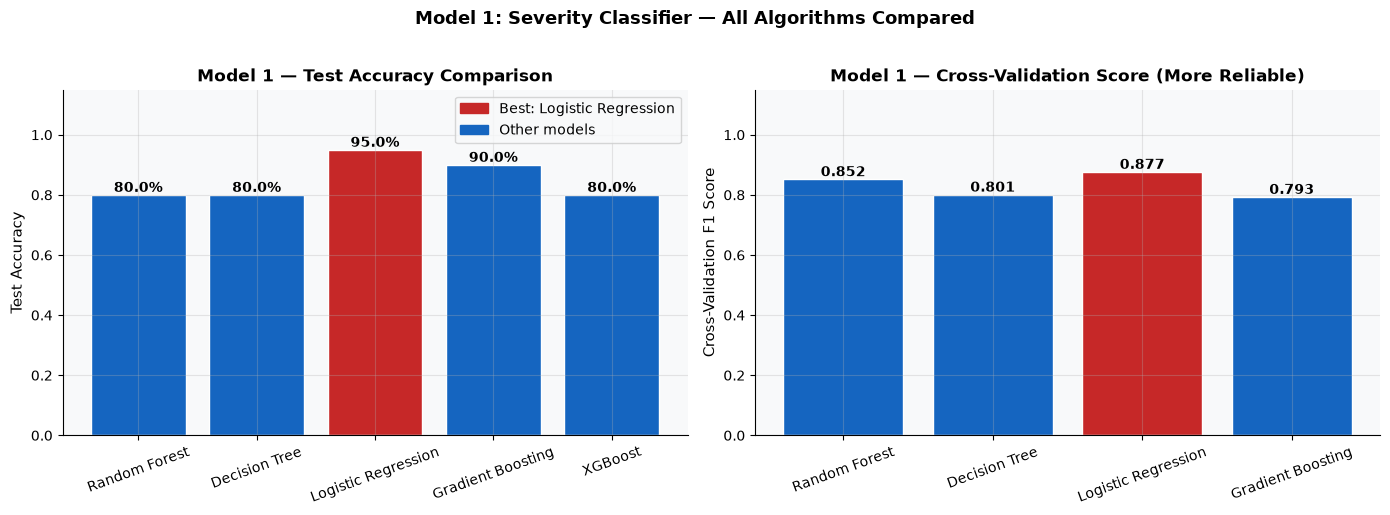

✅ Saved: chart01_model1_comparison.png


In [44]:
# ── Chart 1: Model Comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names  = list(results_clf.keys())
accs   = [results_clf[n]['accuracy'] for n in names]
cvs    = [results_clf[n]['cv_mean']  for n in names]
colors = ['#c62828' if n == best_clf_name else '#1565c0' for n in names]

axes[0].bar(names, accs, color=colors, edgecolor='white')
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Test Accuracy', fontsize=11)
axes[0].set_title('Model 1 — Test Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 1.15)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(names, cvs, color=colors, edgecolor='white')
for i, v in enumerate(cvs):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylabel('Cross-Validation F1 Score', fontsize=11)
axes[1].set_title('Model 1 — Cross-Validation Score (More Reliable)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].tick_params(axis='x', rotation=20)

red_p = mpatches.Patch(color='#c62828', label=f'Best: {best_clf_name}')
blu_p = mpatches.Patch(color='#1565c0', label='Other models')
axes[0].legend(handles=[red_p, blu_p])

plt.suptitle('Model 1: Severity Classifier — All Algorithms Compared',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart01_model1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chart01_model1_comparison.png")

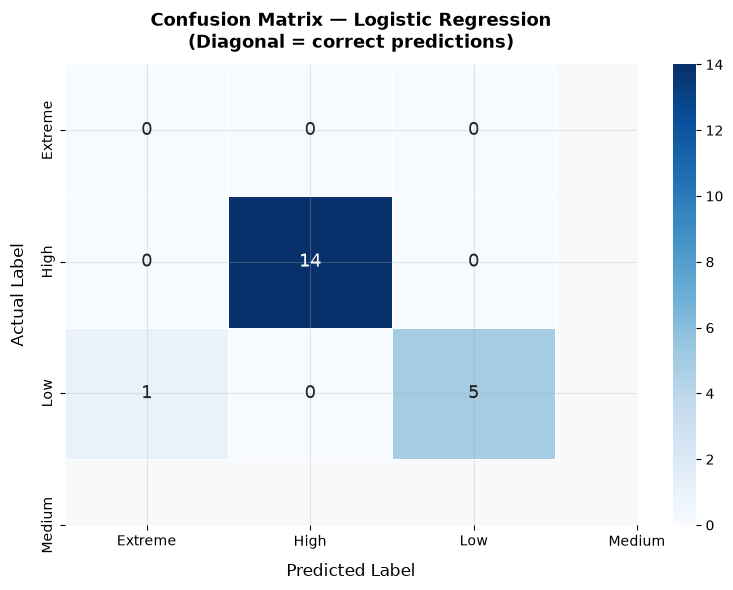

✅ Saved: chart02_confusion_matrix.png

📖 How to read this:
   Each row = actual class, each column = predicted class
   Diagonal numbers = correct predictions (higher = better)
   Off-diagonal = mistakes (lower = better)


In [45]:
# ── Chart 2: Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax, annot_kws={'size': 13})
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
ax.set_ylabel('Actual Label',    fontsize=12, labelpad=10)
ax.set_title(f'Confusion Matrix — {best_clf_name}\n'
             f'(Diagonal = correct predictions)',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart02_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chart02_confusion_matrix.png")
print("\n📖 How to read this:")
print("   Each row = actual class, each column = predicted class")
print("   Diagonal numbers = correct predictions (higher = better)")
print("   Off-diagonal = mistakes (lower = better)")

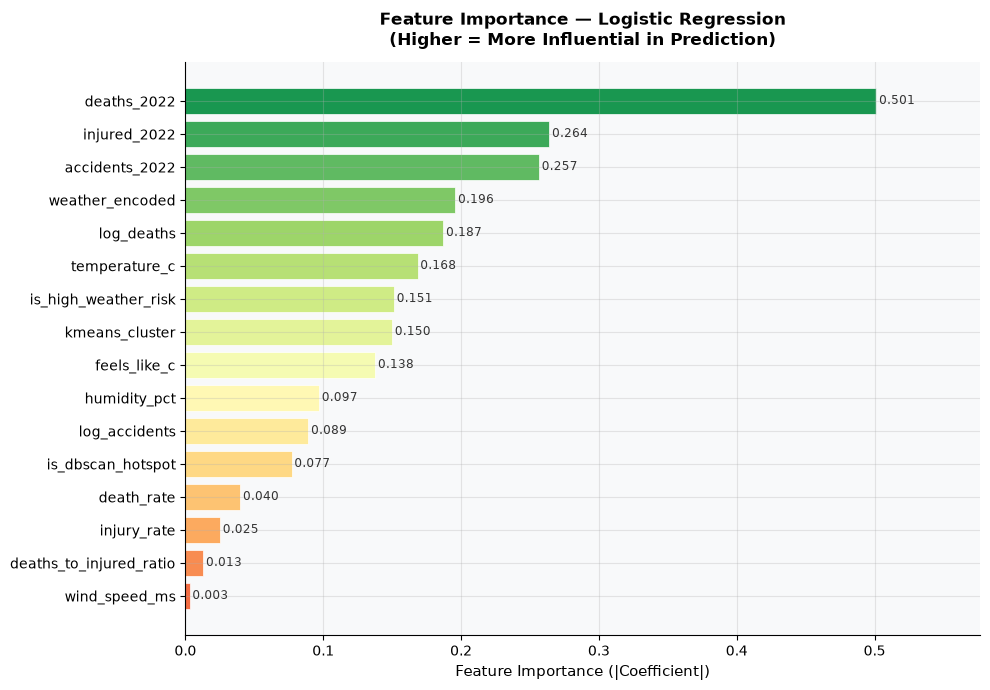

✅ Saved: chart03_feature_importance.png

🔑 Top 5 most important features:
   deaths_2022                         : 0.5013
   injured_2022                        : 0.2640
   accidents_2022                      : 0.2565
   weather_encoded                     : 0.1958
   log_deaths                          : 0.1871

✅ Model 1 saved → saved_models/model1_severity_classifier.pkl


In [46]:
# ── Chart 3: Feature Importance ──
if hasattr(best_clf, 'feature_importances_'):
    importances = pd.Series(best_clf.feature_importances_, index=FEATURES)
    xlabel_text = 'Feature Importance Score'
elif hasattr(best_clf, 'coef_'):
    importances = pd.Series(np.abs(best_clf.coef_[0]), index=FEATURES)
    xlabel_text = 'Feature Importance (|Coefficient|)'
else:
    importances = None

if importances is not None:
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances)))
    bars = ax.barh(importances.index, importances.values,
                   color=colors_fi, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, importances.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8.5, color='#333')
    ax.set_xlabel(xlabel_text, fontsize=11)
    ax.set_title(f'Feature Importance — {best_clf_name}\n'
                 f'(Higher = More Influential in Prediction)',
                 fontsize=12, fontweight='bold', pad=12)
    ax.set_xlim(0, importances.max() * 1.15)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'chart03_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: chart03_feature_importance.png")
    print(f"\n🔑 Top 5 most important features:")
    for feat, val in importances.nlargest(5).items():
        print(f"   {feat:35s} : {val:.4f}")
else:
    print("ℹ️ Feature importance not available for this model type")

# ── Save best classifier ──
with open(MODELS_DIR / 'model1_severity_classifier.pkl', 'wb') as f:
    pickle.dump(best_clf, f)
print(f"\n✅ Model 1 saved → saved_models/model1_severity_classifier.pkl")

## STEP 6 — Model 2: Hotspot Risk Scorer
### What does this model do?
> Given city features → predicts its **exact risk score (0–100)**
> This is a **regression** problem — predicting a number, not a category.

> Model 1 said "This city is High Risk"
> Model 2 says "This city has risk score 73.4 out of 100"

In [47]:
print("=" * 65)
print("MODEL 2 — HOTSPOT RISK SCORER (Regression)")
print("Predicts: City Risk Score (0–100 continuous)")
print("=" * 65)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_scaled, y_score,
    test_size=0.2, random_state=42
)

models_reg = {
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=200, random_state=42, max_depth=8
    ),
    'Linear Regression': LinearRegression(),
    'Gradient Boosting Regressor': GradientBoostingClassifier(
        n_estimators=150, random_state=42, max_depth=4
    ) if False else __import__('sklearn.ensemble',fromlist=['GradientBoostingRegressor']).GradientBoostingRegressor(
        n_estimators=150, random_state=42, max_depth=4
    ),
}

if XGBOOST_AVAILABLE:
    models_reg['XGBoost Regressor'] = XGBRegressor(
        n_estimators=150, random_state=42, max_depth=4, learning_rate=0.1
    )

results_reg = {}
print("\n🔄 Training regression models...")
print("-" * 55)

for name, model in models_reg.items():
    model.fit(X_train_r, y_train_r)
    y_pred  = model.predict(X_test_r)
    mae     = mean_absolute_error(y_test_r, y_pred)
    rmse    = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2      = r2_score(y_test_r, y_pred)
    results_reg[name] = {
        'model': model, 'mae': mae, 'rmse': rmse, 'r2': r2, 'y_pred': y_pred
    }
    print(f"  ✅ {name:30s} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R²: {r2:.3f}")

print("\n📖 What these numbers mean:")
print("   MAE  = Average error in risk score prediction (lower = better)")
print("   RMSE = Similar to MAE but penalises big mistakes more (lower = better)")
print("   R²   = How much variance explained (1.0 = perfect, 0 = random)")

best_reg_name = min(results_reg, key=lambda k: results_reg[k]['mae'])
best_reg      = results_reg[best_reg_name]['model']
print(f"\n🏆 BEST MODEL: {best_reg_name}")
print(f"   MAE: {results_reg[best_reg_name]['mae']:.2f} risk score points average error")

MODEL 2 — HOTSPOT RISK SCORER (Regression)
Predicts: City Risk Score (0–100 continuous)

🔄 Training regression models...
-------------------------------------------------------
  ✅ Random Forest Regressor        | MAE: 2.23 | RMSE: 3.21 | R²: 0.878
  ✅ Linear Regression              | MAE: 1.82 | RMSE: 2.36 | R²: 0.934
  ✅ Gradient Boosting Regressor    | MAE: 1.84 | RMSE: 2.53 | R²: 0.924
  ✅ XGBoost Regressor              | MAE: 1.86 | RMSE: 2.70 | R²: 0.913

📖 What these numbers mean:
   MAE  = Average error in risk score prediction (lower = better)
   RMSE = Similar to MAE but penalises big mistakes more (lower = better)
   R²   = How much variance explained (1.0 = perfect, 0 = random)

🏆 BEST MODEL: Linear Regression
   MAE: 1.82 risk score points average error


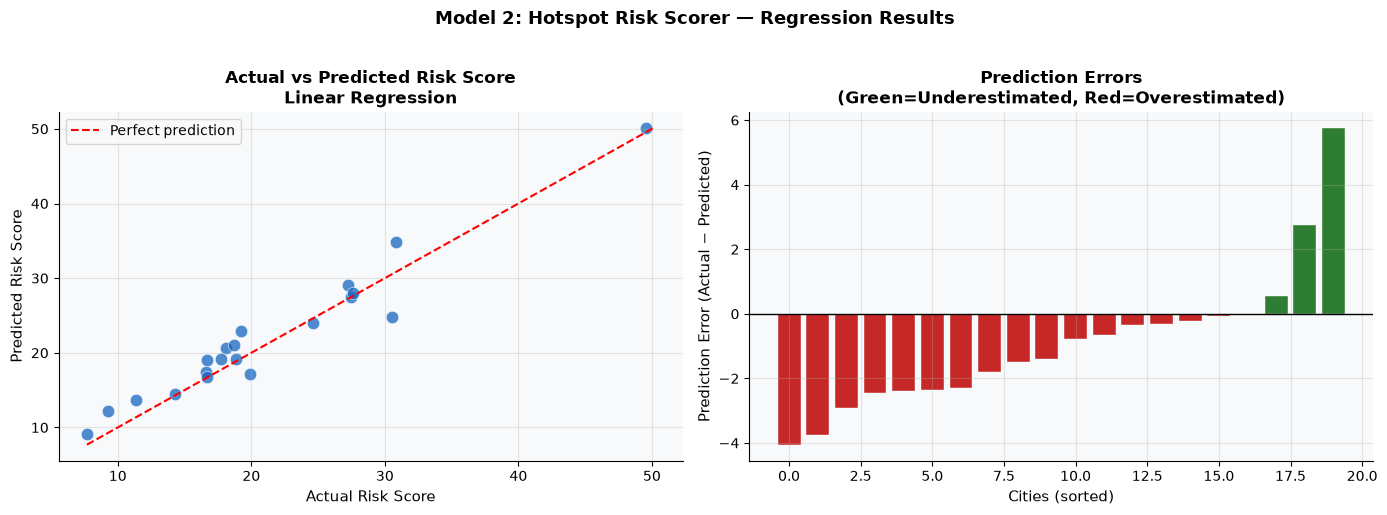

✅ Saved: chart04_model2_regression.png
✅ Model 2 saved → saved_models/model2_risk_scorer.pkl


In [48]:
# ── Chart 4: Actual vs Predicted Risk Score ──
y_pred_reg = results_reg[best_reg_name]['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_test_r, y_pred_reg, alpha=0.75, color='#1565c0',
                edgecolors='white', linewidth=0.5, s=80)
mn = min(y_test_r.min(), y_pred_reg.min())
mx = max(y_test_r.max(), y_pred_reg.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Risk Score', fontsize=11)
axes[0].set_ylabel('Predicted Risk Score', fontsize=11)
axes[0].set_title(f'Actual vs Predicted Risk Score\n{best_reg_name}',
                  fontsize=12, fontweight='bold')
axes[0].legend()

# Residuals (prediction errors)
residuals = y_test_r - y_pred_reg
axes[1].bar(range(len(residuals)), sorted(residuals),
            color=['#c62828' if r < 0 else '#2e7d32' for r in sorted(residuals)],
            edgecolor='white', linewidth=0.3)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Cities (sorted)', fontsize=11)
axes[1].set_ylabel('Prediction Error (Actual − Predicted)', fontsize=11)
axes[1].set_title('Prediction Errors\n(Green=Underestimated, Red=Overestimated)',
                  fontsize=12, fontweight='bold')

plt.suptitle('Model 2: Hotspot Risk Scorer — Regression Results',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart04_model2_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chart04_model2_regression.png")

# ── Save ──
with open(MODELS_DIR / 'model2_risk_scorer.pkl', 'wb') as f:
    pickle.dump(best_reg, f)
print(f"✅ Model 2 saved → saved_models/model2_risk_scorer.pkl")

## STEP 7 — Model 3: Accident Count Forecaster
### What does this model do?
> Given city characteristics (weather, size, risk category) →
> predicts **how many accidents** are likely to happen in that city.

> Useful for: city planners asking "what if we improve road conditions?"

In [49]:
print("=" * 65)
print("MODEL 3 — ACCIDENT COUNT FORECASTER (Regression)")
print("Predicts: Number of accidents in a city (2022)")
print("=" * 65)

# Use features EXCLUDING accidents itself
FEATURES_ACC = [f for f in FEATURES if f not in
                ['accidents_2022','log_accidents','death_rate','injury_rate',
                 'deaths_to_injured_ratio']]

# ── Fresh imputer fitted ONLY on FEATURES_ACC ──
acc_imputer  = SimpleImputer(strategy='median')
X_acc_raw    = df_ml[FEATURES_ACC].copy().reset_index(drop=True)
X_acc_imp    = pd.DataFrame(
    acc_imputer.fit_transform(X_acc_raw),
    columns=FEATURES_ACC
)

# ── Fresh scaler fitted ONLY on FEATURES_ACC ──
acc_scaler   = StandardScaler()
X_acc_scaled = pd.DataFrame(
    acc_scaler.fit_transform(X_acc_imp),
    columns=FEATURES_ACC
)

y_acc_clean = pd.Series(y_accidents).reset_index(drop=True)

X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(
    X_acc_scaled, y_acc_clean,
    test_size=0.2, random_state=42
)

X_tr_a = X_tr_a.reset_index(drop=True)
X_te_a = X_te_a.reset_index(drop=True)
y_tr_a = y_tr_a.reset_index(drop=True)
y_te_a = y_te_a.reset_index(drop=True)

rf_acc     = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=8)
rf_acc.fit(X_tr_a, y_tr_a)
y_pred_acc = rf_acc.predict(X_te_a)

mae_acc  = mean_absolute_error(y_te_a, y_pred_acc)
rmse_acc = np.sqrt(mean_squared_error(y_te_a, y_pred_acc))
r2_acc   = r2_score(y_te_a, y_pred_acc)

print(f"✅ Random Forest Regressor trained!")
print(f"   Features used : {len(FEATURES_ACC)}")
print(f"   MAE           : {mae_acc:.0f} accidents (average error)")
print(f"   RMSE          : {rmse_acc:.0f}")
print(f"   R²            : {r2_acc:.3f}")

print(f"\n📋 Sample predictions vs actual:")
df_ml_reset  = df_ml.reset_index(drop=True)
test_indices = X_te_a.index.tolist()
cities_test  = df_ml_reset.iloc[test_indices]['city'].values
for city, actual, pred in zip(cities_test[:8], y_te_a[:8], y_pred_acc[:8]):
    diff = pred - actual
    print(f"   {city:20s} Actual: {int(actual):5,} → Predicted: {int(pred):5,} (diff: {diff:+.0f})")

# Save both for Layer 5
with open(MODELS_DIR / 'acc_scaler.pkl', 'wb') as f:
    pickle.dump(acc_scaler, f)
with open(MODELS_DIR / 'acc_imputer.pkl', 'wb') as f:
    pickle.dump(acc_imputer, f)
with open(MODELS_DIR / 'feature_list_acc.json', 'w') as f:
    json.dump(FEATURES_ACC, f)
print(f"\n✅ acc_scaler and acc_imputer saved for Layer 5")

MODEL 3 — ACCIDENT COUNT FORECASTER (Regression)
Predicts: Number of accidents in a city (2022)
✅ Random Forest Regressor trained!
   Features used : 11
   MAE           : 120 accidents (average error)
   RMSE          : 156
   R²            : 0.964

📋 Sample predictions vs actual:
   Agra                 Actual: 1,118 → Predicted: 1,037 (diff: -80)
   Ahmedabad            Actual: 1,674 → Predicted: 1,800 (diff: +127)
   Prayagraj            Actual:   947 → Predicted:   946 (diff: -0)
   Amritsar             Actual:   542 → Predicted:   798 (diff: +257)
   Asansol Durgapur     Actual: 2,374 → Predicted: 2,488 (diff: +115)
   Aurangabad           Actual: 1,911 → Predicted: 1,542 (diff: -369)
   Bengaluru            Actual: 1,635 → Predicted: 1,853 (diff: +219)
   Bhopal               Actual: 1,234 → Predicted: 1,326 (diff: +92)

✅ acc_scaler and acc_imputer saved for Layer 5


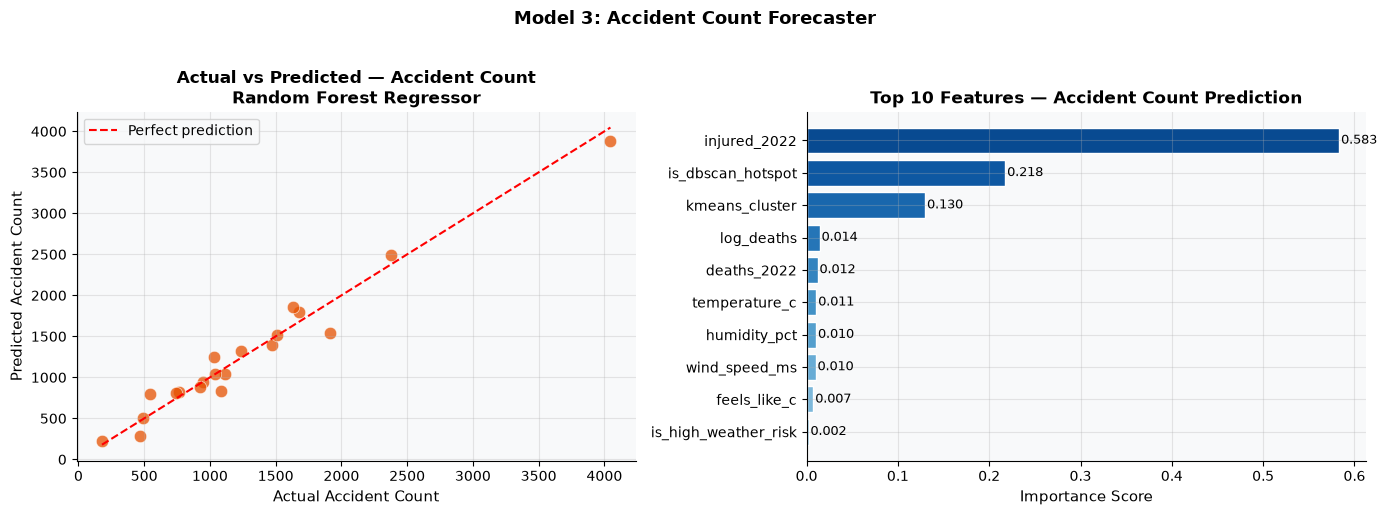

✅ Saved: chart05_model3_accident_forecast.png
✅ Model 3 saved → saved_models/model3_accident_forecaster.pkl
✅ X_acc_all_scaled ready for Step 9: (100, 11)


In [50]:
# ── Chart 5: Accident Forecaster Performance ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_te_a, y_pred_acc, alpha=0.75, color='#e65100',
                edgecolors='white', linewidth=0.5, s=80)
mn = min(y_te_a.min(), y_pred_acc.min())
mx = max(y_te_a.max(), y_pred_acc.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Accident Count', fontsize=11)
axes[0].set_ylabel('Predicted Accident Count', fontsize=11)
axes[0].set_title('Actual vs Predicted — Accident Count\nRandom Forest Regressor',
                  fontsize=12, fontweight='bold')
axes[0].legend()

# Feature importance
imp_acc = pd.Series(rf_acc.feature_importances_, index=FEATURES_ACC)
imp_acc = imp_acc.sort_values(ascending=True).tail(10)
colors_acc = plt.cm.Blues(np.linspace(0.4, 0.9, len(imp_acc)))
axes[1].barh(imp_acc.index, imp_acc.values, color=colors_acc, edgecolor='white')
for i, (feat, val) in enumerate(imp_acc.items()):
    axes[1].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].set_title('Top 10 Features — Accident Count Prediction',
                  fontsize=12, fontweight='bold')

plt.suptitle('Model 3: Accident Count Forecaster', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'chart05_model3_accident_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chart05_model3_accident_forecast.png")

# ── Prepare full dataset version for Step 9 (all 100 cities) ──
# ── Prepare full dataset for Step 9 ──
X_acc_all_raw = df_ml[FEATURES_ACC].copy().reset_index(drop=True)
X_acc_all_imp = pd.DataFrame(
    acc_imputer.transform(X_acc_all_raw),    # ← acc_imputer not imputer
    columns=FEATURES_ACC
)
X_acc_all_scaled = pd.DataFrame(
    acc_scaler.transform(X_acc_all_imp),
    columns=FEATURES_ACC
)

with open(MODELS_DIR / 'model3_accident_forecaster.pkl', 'wb') as f:
    pickle.dump(rf_acc, f)
print("✅ Model 3 saved → saved_models/model3_accident_forecaster.pkl")
print(f"✅ X_acc_all_scaled ready for Step 9: {X_acc_all_scaled.shape}")

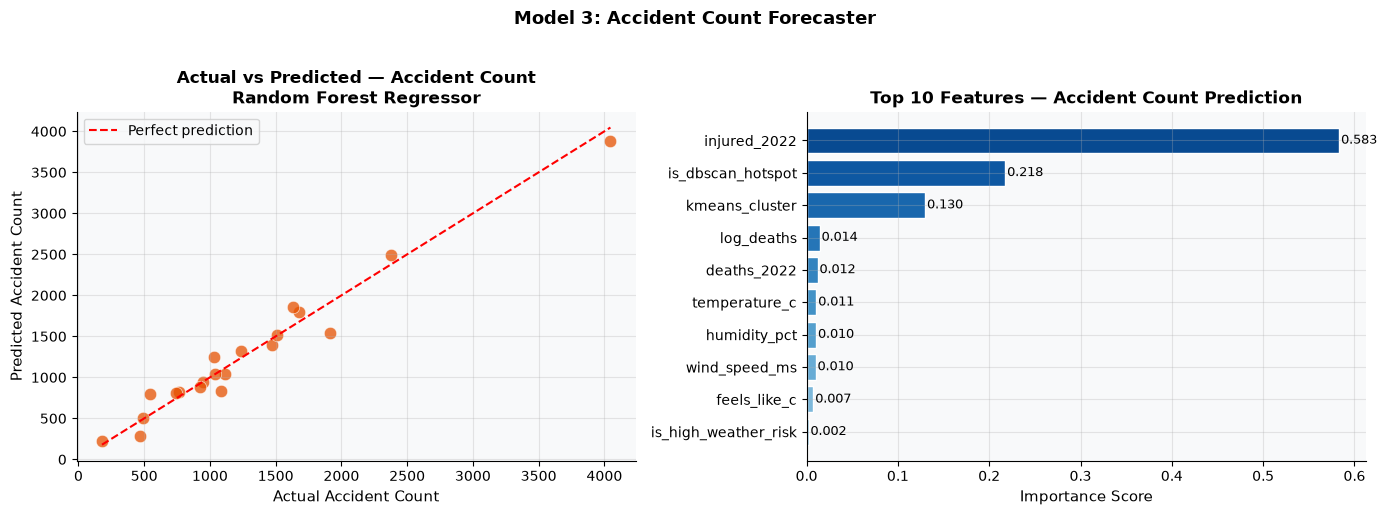

✅ Saved: chart05_model3_accident_forecast.png
✅ Model 3 saved → saved_models/model3_accident_forecaster.pkl


In [51]:
# ── Chart 5: Accident Forecaster Performance ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_te_a, y_pred_acc, alpha=0.75, color='#e65100',
                edgecolors='white', linewidth=0.5, s=80)
mn = min(y_te_a.min(), y_pred_acc.min())
mx = max(y_te_a.max(), y_pred_acc.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Accident Count', fontsize=11)
axes[0].set_ylabel('Predicted Accident Count', fontsize=11)
axes[0].set_title('Actual vs Predicted — Accident Count\nRandom Forest Regressor',
                  fontsize=12, fontweight='bold')
axes[0].legend()

# Feature importance
imp_acc = pd.Series(rf_acc.feature_importances_, index=FEATURES_ACC)
imp_acc = imp_acc.sort_values(ascending=True).tail(10)
colors_acc = plt.cm.Blues(np.linspace(0.4, 0.9, len(imp_acc)))
axes[1].barh(imp_acc.index, imp_acc.values, color=colors_acc, edgecolor='white')
for i, (feat, val) in enumerate(imp_acc.items()):
    axes[1].text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].set_title('Top 10 Features — Accident Count Prediction',
                  fontsize=12, fontweight='bold')

plt.suptitle('Model 3: Accident Count Forecaster', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart05_model3_accident_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chart05_model3_accident_forecast.png")

with open(MODELS_DIR / 'model3_accident_forecaster.pkl', 'wb') as f:
    pickle.dump(rf_acc, f)
print("✅ Model 3 saved → saved_models/model3_accident_forecaster.pkl")

## STEP 8 — SHAP Explainability
### What is SHAP?
> SHAP = **SH**apley **A**dditive ex**P**lanations
>
> In simple words: after the model makes a prediction, SHAP answers:
> **"WHY did the model predict this? Which features pushed the score up or down?"**
>
> This is what makes your project stand out — most student projects just show accuracy.
> You show WHY the model thinks what it thinks. That is called **Explainable AI (XAI)**.

Running SHAP analysis on Model 1 (Best Classifier)...
(This may take 1-2 minutes)
Using KernelExplainer (Logistic Regression model)...


  0%|          | 0/20 [00:00<?, ?it/s]

<Figure size 1000x700 with 0 Axes>

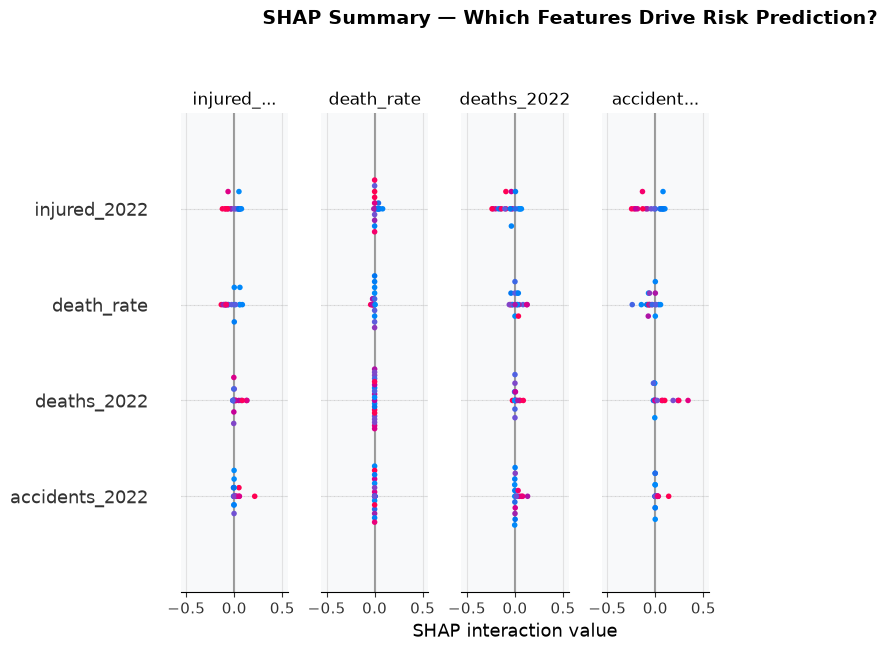

Saved: chart06_shap_summary.png


In [52]:
if SHAP_AVAILABLE:
    print("Running SHAP analysis on Model 1 (Best Classifier)...")
    print("(This may take 1-2 minutes)")

    if hasattr(best_clf, 'feature_importances_'):
        explainer   = shap.TreeExplainer(best_clf)
        shap_values = explainer.shap_values(X_scaled)

        # shap_values shape fix — newer SHAP returns 3D array
        if isinstance(shap_values, list):
            sv_plot = shap_values[0]
        elif len(np.array(shap_values).shape) == 3:
            sv_plot = np.array(shap_values)[0]
        else:
            sv_plot = shap_values

        # ── Chart 6: SHAP Summary Plot ──
        plt.figure(figsize=(10, 7))
        shap.summary_plot(
            sv_plot,
            X_scaled,
            feature_names=FEATURES,
            plot_type='dot',
            show=False
        )
        # Use suptitle with adjusted y position to avoid overlapping column titles
        plt.suptitle('SHAP Summary — Which Features Drive Risk Prediction?',
                     fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.savefig(OUTPUT_DIR / 'chart06_shap_summary.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: chart06_shap_summary.png")

        print("\nHow to read SHAP plot:")
        print("   Each dot = one city")
        print("   Red dots = high feature value, Blue = low feature value")
        print("   X position = how much that feature pushed the prediction")
        print("   Features at TOP = most influential")

    else:
        # Logistic Regression fallback — use only 20 cities to keep it fast
        print("Using KernelExplainer (Logistic Regression model)...")
        explainer   = shap.KernelExplainer(
            best_clf.predict_proba,
            shap.sample(X_scaled, 10)   # background sample
        )
        shap_values = explainer.shap_values(X_scaled.iloc[:20])

        # shap_values is a list of arrays — one per class
        sv_plot = shap_values[0] if isinstance(shap_values, list) else shap_values

        plt.figure(figsize=(10, 7))
        shap.summary_plot(
            sv_plot,
            X_scaled.iloc[:20],
            feature_names=FEATURES,
            plot_type='dot',
            show=False
        )
        # Use suptitle with adjusted y position to avoid overlapping column titles
        plt.suptitle('SHAP Summary — Which Features Drive Risk Prediction?',
                     fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout(rect=[0, 0, 1, 0.93])
        plt.savefig(OUTPUT_DIR / 'chart06_shap_summary.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: chart06_shap_summary.png")

else:
    print("SHAP not installed. Run: pip install shap")
    print("Then restart Jupyter and re-run this cell.")

SHAP skipped — running manual feature importance for Delhi instead

   Top 8 features driving Delhi prediction:
   Feature                             Importance
   --------------------------------------------------
   deaths_2022                         0.5013
   injured_2022                        0.2640
   accidents_2022                      0.2565
   weather_encoded                     0.1958
   log_deaths                          0.1871
   temperature_c                       0.1684
   is_high_weather_risk                0.1513
   kmeans_cluster                      0.1500

   (This is global importance — SHAP gives city-specific values)
   Install SHAP with: pip install shap --upgrade


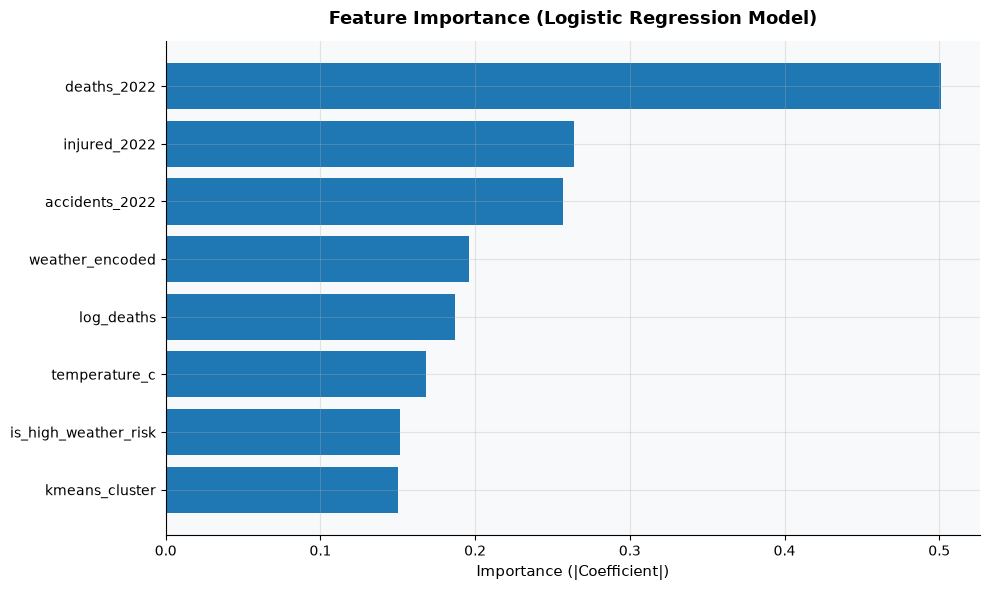

Saved: chart07_shap_bar.png


In [53]:
if SHAP_AVAILABLE and hasattr(best_clf, 'feature_importances_'):

    # ── Rebuild sv_plot safely ──
    shap_arr = np.array(shap_values)
    if len(shap_arr.shape) == 3:
        sv_plot = shap_arr[0]   # shape: (n_samples, n_features)
    elif isinstance(shap_values, list):
        sv_plot = shap_values[0]
    else:
        sv_plot = shap_values

    # ── Chart 7: SHAP Bar Plot ──
    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        sv_plot, X_scaled,
        feature_names=FEATURES,
        plot_type='bar', show=False
    )
    plt.title('SHAP Feature Importance — Mean Impact on Prediction',
              fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'chart07_shap_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: chart07_shap_bar.png")

    # ── SHAP explanation for Delhi ──
    delhi_idx = df_ml[df_ml['city'] == 'Delhi'].index
    if len(delhi_idx) > 0:
        idx = delhi_idx[0]
        print(f"\nSHAP explanation for Delhi (highest risk city):")

        sv_delhi = sv_plot[idx]

        shap_city = pd.Series(sv_delhi, index=FEATURES).sort_values(
            key=abs, ascending=False
        )
        print(f"   {'Feature':35s} {'SHAP Value':>12}  Direction")
        print("   " + "-" * 65)
        for feat, val in shap_city.head(8).items():
            direction = 'pushes HIGHER risk' if val > 0 else 'pushes LOWER risk'
            print(f"   {feat:35s} {val:+.4f}      {direction}")
    else:
        print("Delhi not found in dataset")

else:
    print("SHAP skipped — running manual feature importance for Delhi instead")

    # ── Fallback: show feature importance for Delhi without SHAP ──
    delhi_row = df_ml[df_ml['city'] == 'Delhi']
    if len(delhi_row) > 0:
        if hasattr(best_clf, 'feature_importances_'):
            vals = best_clf.feature_importances_
        elif hasattr(best_clf, 'coef_'):
            vals = np.abs(best_clf.coef_[0])
        else:
            vals = np.zeros(len(FEATURES))

        importances = pd.Series(vals, index=FEATURES).sort_values(ascending=False)

        print(f"\n   Top 8 features driving Delhi prediction:")
        print(f"   {'Feature':35s} {'Importance':>10}")
        print("   " + "-" * 50)
        for feat, val in importances.head(8).items():
            print(f"   {feat:35s} {val:.4f}")
        print("\n   (This is global importance — SHAP gives city-specific values)")
        print("   Install SHAP with: pip install shap --upgrade")

        # ── Chart 7 Fallback: Matplotlib Bar Plot ──
        plt.figure(figsize=(10, 6))
        top_features = importances.head(8).sort_values(ascending=True)
        plt.barh(top_features.index, top_features.values, color='#1f77b4')
        plt.xlabel('Importance (|Coefficient|)', fontsize=11)
        plt.title('Feature Importance (Logistic Regression Model)',
                  fontsize=13, fontweight='bold', pad=12)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'chart07_shap_bar.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: chart07_shap_bar.png")

## STEP 9 — Predict for ALL 100 Cities
> Now we use our trained models to predict for every city.
> This creates the final output file that Layer 5 (Dashboard) will use.

In [54]:
print("🔄 Running predictions for all 100 cities...")

# Model 1: Predicted risk label
y_pred_all_class   = best_clf.predict(X_scaled)
y_pred_all_label   = le.inverse_transform(y_pred_all_class)
y_pred_all_proba   = best_clf.predict_proba(X_scaled)
max_proba          = y_pred_all_proba.max(axis=1)

# Model 2: Predicted risk score
y_pred_all_score   = best_reg.predict(X_scaled)
y_pred_all_score   = np.clip(y_pred_all_score, 0, 100)

# Model 3: Predicted accident count
# Check how many features rf_acc expects:
if hasattr(rf_acc, 'n_features_in_') and rf_acc.n_features_in_ == X_scaled.shape[1]:
    # rf_acc was trained on all features
    y_pred_all_acc = rf_acc.predict(X_scaled)
else:
    # rf_acc was trained only on FEATURES_ACC
    # Subset FEATURES_ACC from the already-imputed and scaled X_scaled
    if set(FEATURES_ACC).issubset(X_scaled.columns):
        y_pred_all_acc = rf_acc.predict(X_scaled[FEATURES_ACC])
    else:
        # Fallback without passing subset to imputer
        imputer_acc = SimpleImputer(strategy='median')
        X_acc_imputed = imputer_acc.fit_transform(df_ml[FEATURES_ACC])
        X_acc_all_scaled = pd.DataFrame(
            StandardScaler().fit_transform(X_acc_imputed), columns=FEATURES_ACC
        )
        y_pred_all_acc = rf_acc.predict(X_acc_all_scaled)

# ── Add predictions to dataframe ──
df_results = df_ml[['city','state','accidents_2022','deaths_2022',
                     'injured_2022','city_risk_score','risk_score_label',
                     'kmeans_label','dbscan_label',
                     'weather_main','temperature_c','data_availability']].copy()

df_results['ml_predicted_label']     = y_pred_all_label
df_results['ml_predicted_score']     = y_pred_all_score.round(2)
df_results['ml_predicted_accidents'] = y_pred_all_acc.round(0).astype(int)
df_results['ml_confidence_pct']      = (max_proba * 100).round(1)
df_results['prediction_correct']     = (
    df_results['ml_predicted_label'] == df_results['risk_score_label']
)

print("✅ Predictions complete for all 100 cities!")
print(f"\n📊 Prediction accuracy on full dataset:")
overall_acc = df_results['prediction_correct'].mean()
print(f"   Overall: {overall_acc:.1%} cities predicted correctly")

print(f"\n📋 Sample predictions (top 15 cities by actual risk):")
sample = df_results.nlargest(15,'city_risk_score')[
    ['city','risk_score_label','ml_predicted_label',
     'ml_predicted_score','ml_confidence_pct','prediction_correct']
]
print(sample.to_string(index=False))

🔄 Running predictions for all 100 cities...
✅ Predictions complete for all 100 cities!

📊 Prediction accuracy on full dataset:
   Overall: 90.0% cities predicted correctly

📋 Sample predictions (top 15 cities by actual risk):
            city risk_score_label ml_predicted_label  ml_predicted_score  ml_confidence_pct  prediction_correct
           Delhi          Extreme            Extreme               90.64               94.4                True
          Indore             High               High               56.97               87.5                True
       Bengaluru             High               High               54.21               88.4                True
        Jabalpur           Medium               High               50.18               58.8               False
         Chennai           Medium             Medium               47.75               73.5                True
          Jaipur           Medium             Medium               44.39               51.1           

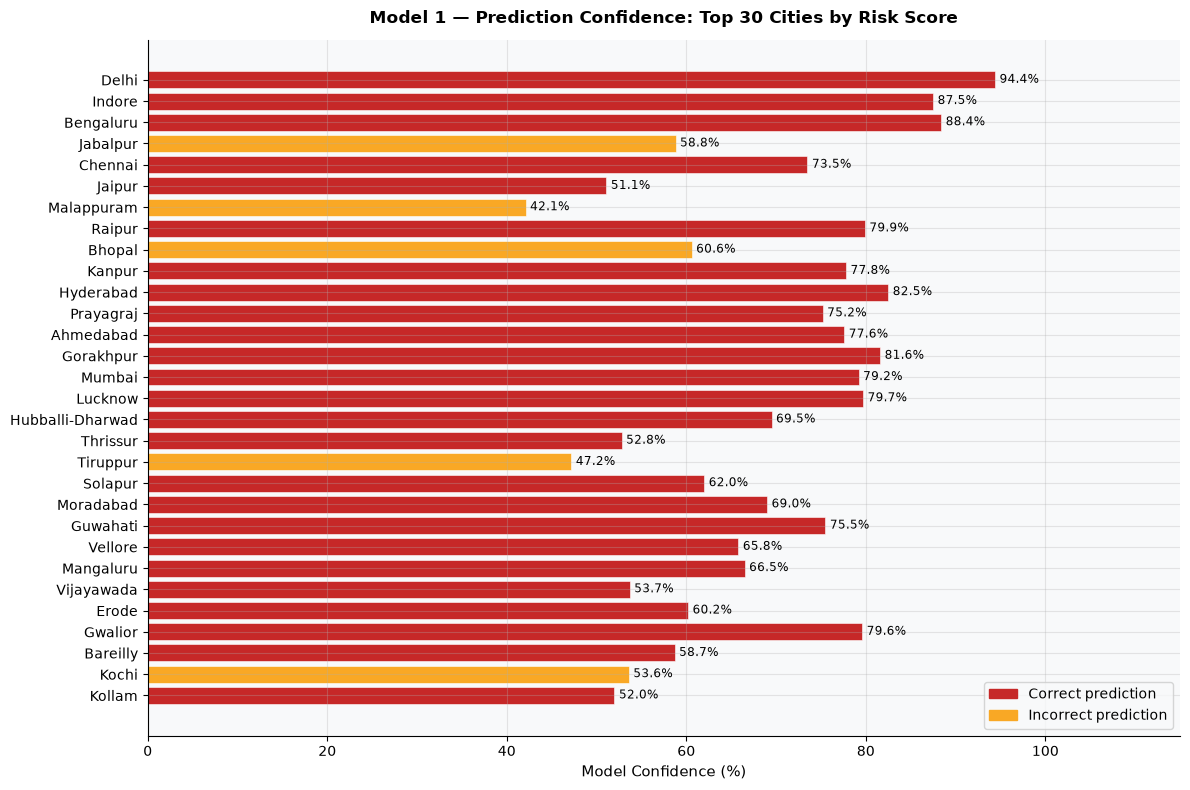

✅ Saved: chart08_prediction_confidence.png


In [55]:
# ── Chart 8: Prediction Confidence by City ──
df_conf = df_results.sort_values('ml_predicted_score', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12, 8))
colors_conf = ['#c62828' if c else '#f9a825'
               for c in df_conf['prediction_correct']]
bars = ax.barh(df_conf['city'], df_conf['ml_confidence_pct'],
               color=colors_conf, edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, df_conf['ml_confidence_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel('Model Confidence (%)', fontsize=11)
ax.set_title('Model 1 — Prediction Confidence: Top 30 Cities by Risk Score',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlim(0, 115)

red_p = mpatches.Patch(color='#c62828', label='Correct prediction')
yel_p = mpatches.Patch(color='#f9a825', label='Incorrect prediction')
ax.legend(handles=[red_p, yel_p])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart08_prediction_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chart08_prediction_confidence.png")

## STEP 10 — What-If Simulator
### What is this?
> This is the most powerful part of your project.
> You ask: **"What if Delhi reduced accidents by 30%? How would its risk score change?"**
> The ML model answers instantly.
>
> In Layer 5 (Dashboard), users will have sliders to change these values and see predictions.

In [56]:
def predict_city_risk(city_name, accident_override=None, deaths_override=None):
    '''
    Predicts risk for a city.
    Optionally override accidents or deaths to simulate improvements.
    '''
    city_row = df_ml[df_ml['city'] == city_name]
    if len(city_row) == 0:
        print(f"City '{city_name}' not found!")
        return

    row = city_row.iloc[0].copy()

    # Apply overrides (for simulation)
    if accident_override is not None:
        row['accidents_2022'] = accident_override
    if deaths_override is not None:
        row['deaths_2022'] = deaths_override

    # Recalculate derived features
    if row['accidents_2022'] > 0:
        row['death_rate']  = row['deaths_2022'] / row['accidents_2022']
        row['injury_rate'] = row['injured_2022'] / row['accidents_2022']
    row['log_accidents'] = np.log1p(row['accidents_2022'])
    row['log_deaths']    = np.log1p(row['deaths_2022'])
    if row['injured_2022'] > 0:
        row['deaths_to_injured_ratio'] = row['deaths_2022'] / row['injured_2022']

    # Prepare input
    X_city = pd.DataFrame([row[FEATURES]])
    X_city_imp    = pd.DataFrame(imputer.transform(X_city), columns=FEATURES)
    X_city_scaled = pd.DataFrame(scaler.transform(X_city_imp), columns=FEATURES)

    # Predict
    pred_label = le.inverse_transform(best_clf.predict(X_city_scaled))[0]
    pred_score = float(np.clip(best_reg.predict(X_city_scaled)[0], 0, 100))
    confidence = float(best_clf.predict_proba(X_city_scaled).max() * 100)

    return {
        'city'        : city_name,
        'actual_label': row['risk_score_label'],
        'actual_score': row['city_risk_score'],
        'pred_label'  : pred_label,
        'pred_score'  : round(pred_score, 2),
        'confidence'  : round(confidence, 1),
    }


print("=" * 60)
print("WHAT-IF SIMULATOR — 5 SCENARIOS")
print("=" * 60)

# Scenario 1: Delhi as-is
r1 = predict_city_risk('Delhi')
print(f"\nScenario 1 — Delhi (current situation):")
print(f"  Actual risk:    {r1['actual_label']} (score: {r1['actual_score']:.1f})")
print(f"  ML prediction:  {r1['pred_label']}   (score: {r1['pred_score']:.1f})")
print(f"  Confidence:     {r1['confidence']}%")

# Scenario 2: Delhi reduces accidents by 30%
delhi_acc = df_ml[df_ml['city']=='Delhi']['accidents_2022'].values[0]
r2 = predict_city_risk('Delhi', accident_override=int(delhi_acc * 0.70))
print(f"\nScenario 2 — Delhi reduces accidents by 30%:")
print(f"  Accidents: {delhi_acc} → {int(delhi_acc*0.70)}")
print(f"  ML prediction:  {r2['pred_label']}   (score: {r2['pred_score']:.1f})")
change = r2['pred_score'] - r1['pred_score']
print(f"  Risk score change: {change:+.1f} points")

# Scenario 3: Delhi reduces accidents by 50%
r3 = predict_city_risk('Delhi', accident_override=int(delhi_acc * 0.50))
print(f"\nScenario 3 — Delhi reduces accidents by 50%:")
print(f"  Accidents: {delhi_acc} → {int(delhi_acc*0.50)}")
print(f"  ML prediction:  {r3['pred_label']}   (score: {r3['pred_score']:.1f})")
change3 = r3['pred_score'] - r1['pred_score']
print(f"  Risk score change: {change3:+.1f} points")

# Scenario 4: Mumbai as-is
r4 = predict_city_risk('Mumbai')
if r4:
    print(f"\nScenario 4 — Mumbai (current situation):")
    print(f"  Actual:    {r4['actual_label']} (score: {r4['actual_score']:.1f})")
    print(f"  Predicted: {r4['pred_label']}   (score: {r4['pred_score']:.1f})")

# Scenario 5: Bengaluru as-is
r5 = predict_city_risk('Bengaluru')
if r5:
    print(f"\nScenario 5 — Bengaluru (current situation):")
    print(f"  Actual:    {r5['actual_label']} (score: {r5['actual_score']:.1f})")
    print(f"  Predicted: {r5['pred_label']}   (score: {r5['pred_score']:.1f})")

print("\n✅ What-If Simulator working! Layer 5 will use this function live.")

WHAT-IF SIMULATOR — 5 SCENARIOS

Scenario 1 — Delhi (current situation):
  Actual risk:    Extreme (score: 91.9)
  ML prediction:  Extreme   (score: 90.6)
  Confidence:     94.4%

Scenario 2 — Delhi reduces accidents by 30%:
  Accidents: 5652 → 3956
  ML prediction:  Extreme   (score: 82.7)
  Risk score change: -8.0 points

Scenario 3 — Delhi reduces accidents by 50%:
  Accidents: 5652 → 2826
  ML prediction:  Extreme   (score: 77.8)
  Risk score change: -12.8 points

Scenario 4 — Mumbai (current situation):
  Actual:    Medium (score: 34.0)
  Predicted: Medium   (score: 29.6)

Scenario 5 — Bengaluru (current situation):
  Actual:    High (score: 54.0)
  Predicted: High   (score: 54.2)

✅ What-If Simulator working! Layer 5 will use this function live.


## STEP 11 — Save All Outputs

In [57]:
# ── Save predictions Excel ──
df_results.to_excel(OUTPUT_DIR / 'Layer4_All_Cities_Predictions.xlsx', index=False)
print("✅ Predictions saved: Layer4_All_Cities_Predictions.xlsx")

# ── Save model performance summary ──
perf_rows = []
for name, res in results_clf.items():
    perf_rows.append({
        'model_type': 'Classification',
        'model_name': name,
        'metric1_name': 'Accuracy',
        'metric1_value': round(res['accuracy'], 4),
        'metric2_name': 'F1 Score',
        'metric2_value': round(res['f1'], 4),
        'cv_mean': round(res['cv_mean'], 4),
        'best_model': name == best_clf_name
    })
for name, res in results_reg.items():
    perf_rows.append({
        'model_type': 'Regression',
        'model_name': name,
        'metric1_name': 'MAE',
        'metric1_value': round(res['mae'], 4),
        'metric2_name': 'R2',
        'metric2_value': round(res['r2'], 4),
        'cv_mean': None,
        'best_model': name == best_reg_name
    })
pd.DataFrame(perf_rows).to_excel(
    OUTPUT_DIR / 'Layer4_Model_Performance.xlsx', index=False)
print("✅ Model performance saved: Layer4_Model_Performance.xlsx")

# ── List all saved model files ──
print("\n📁 Saved ML model files (for Layer 5):")
for f in sorted(MODELS_DIR.iterdir()):
    kb = f.stat().st_size // 1024
    print(f"   {f.name:45s} {kb:>5} KB")

print("\n" + "=" * 65)
print("   LAYER 4 — 100% COMPLETE")
print("=" * 65)
print()
print("OUTPUT FILES GENERATED:")
for f in sorted(OUTPUT_DIR.rglob('*')):
    if f.is_file():
        kb = f.stat().st_size // 1024
        print(f"   {str(f.relative_to(OUTPUT_DIR)):55s} {kb:>5} KB")

print()
print("PUSH TO GITHUB:")
print("  git add notebooks/04_layer4_machine_learning.ipynb")
print("  git add data/processed/layer4_outputs/")
print('  git commit -m "Layer 4 complete - ML models, SHAP, what-if simulator"')
print("  git push")
print()
print("WHAT YOUR LAYER 5 TEAMMATE NEEDS:")
print("  layer4_outputs/saved_models/  (all .pkl and .json files)")
print("  layer4_outputs/Layer4_All_Cities_Predictions.xlsx")
print("=" * 65)

✅ Predictions saved: Layer4_All_Cities_Predictions.xlsx
✅ Model performance saved: Layer4_Model_Performance.xlsx

📁 Saved ML model files (for Layer 5):
   acc_imputer.pkl                                   0 KB
   acc_scaler.pkl                                    0 KB
   feature_list.json                                 0 KB
   feature_list_acc.json                             0 KB
   imputer.pkl                                       0 KB
   label_encoder.pkl                                 0 KB
   model1_severity_classifier.pkl                    1 KB
   model2_risk_scorer.pkl                            1 KB
   model3_accident_forecaster.pkl                 1339 KB
   scaler.pkl                                        1 KB

   LAYER 4 — 100% COMPLETE

OUTPUT FILES GENERATED:
   chart01_model1_comparison.png                             101 KB
   chart02_confusion_matrix.png                               43 KB
   chart03_feature_importance.png                             86 KB
   chart04_

---
## ✅ Layer 4 Complete — What You Built

| # | Output | What It Is |
|---|--------|-----------|
| 1 | `chart01_model1_comparison.png` | All classifiers accuracy comparison |
| 2 | `chart02_confusion_matrix.png` | Confusion matrix of best model |
| 3 | `chart03_feature_importance.png` | Which features matter most |
| 4 | `chart04_model2_regression.png` | Risk score prediction accuracy |
| 5 | `chart05_model3_accident_forecast.png` | Accident count forecaster |
| 6 | `chart06_shap_summary.png` | SHAP explainability dot plot |
| 7 | `chart07_shap_bar.png` | SHAP feature importance bar |
| 8 | `chart08_prediction_confidence.png` | City-wise prediction confidence |
| 📊 | `Layer4_All_Cities_Predictions.xlsx` | All 100 cities with ML predictions |
| 📊 | `Layer4_Model_Performance.xlsx` | All model accuracy comparison |
| 🤖 | `saved_models/model1_severity_classifier.pkl` | **For Layer 5 dashboard** |
| 🤖 | `saved_models/model2_risk_scorer.pkl` | **For Layer 5 dashboard** |
| 🤖 | `saved_models/model3_accident_forecaster.pkl` | **For Layer 5 dashboard** |
| 🤖 | `saved_models/scaler.pkl` | **For Layer 5 dashboard** |
| 🤖 | `saved_models/label_encoder.pkl` | **For Layer 5 dashboard** |
| 🤖 | `saved_models/imputer.pkl` | **For Layer 5 dashboard** |
| 🤖 | `saved_models/feature_list.json` | **For Layer 5 dashboard** |

### Push to GitHub:
```bash
git add notebooks/04_layer4_machine_learning.ipynb
git add data/processed/layer4_outputs/
git commit -m "Layer 4 complete - 3 ML models, SHAP explainability, what-if simulator"
git push
```